## Modelo de clasificacion de Vehiculos Electricos

### Acerca del Dataset

El Dataset detalla informacion acerca de Vehiculos electricos a bateria (BEVs) y Vehiculos electricos hibridos enchufables (PHEVs) registrados en los Estados Unidos. Entre los atributos detallados se encuentran el fabricante, modelo, año de registro, entre otra informacion relevante.

## Cargado y exploracion del dataset

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

vehiculos_electricos = pd.read_csv("Electric_Vehicle_Population_Data.csv")
vehiculos_electricos.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EBXK,King,Seattle,WA,98178.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,37.0,477309682,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,5YJYGDEE3L,Kitsap,Poulsbo,WA,98370.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,23.0,109705683,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303509e+10
2,KM8KRDAF5P,Kitsap,Olalla,WA,98359.0,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,26.0,230390492,POINT (-122.54729 47.42602),PUGET SOUND ENERGY INC,5.303509e+10
3,5UXTA6C0XM,Kitsap,Seabeck,WA,98380.0,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30.0,0.0,35.0,267929112,POINT (-122.81585 47.64509),PUGET SOUND ENERGY INC,5.303509e+10
4,JTMAB3FV7P,Thurston,Rainier,WA,98576.0,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,2.0,236505139,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC,5.306701e+10


In [16]:
vehiculos_electricos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235692 entries, 0 to 235691
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         235692 non-null  object 
 1   County                                             235689 non-null  object 
 2   City                                               235689 non-null  object 
 3   State                                              235692 non-null  object 
 4   Postal Code                                        235689 non-null  float64
 5   Model Year                                         235692 non-null  int64  
 6   Make                                               235692 non-null  object 
 7   Model                                              235692 non-null  object 
 8   Electric Vehicle Type                              235692 non-null  object

In [17]:
vehiculos_electricos.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,235689.000000,235692.000000,235656.000000,235656.000000,235198.000000,2.356920e+05,2.356890e+05
mean,98177.656463,2021.406658,46.262569,787.268328,28.879519,2.353127e+08,5.298066e+10
std,2524.218661,2.991908,84.045829,7177.668305,14.904644,6.799098e+07,1.521066e+09
min,1731.000000,2000.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2020.000000,0.000000,0.000000,17.000000,2.053457e+08,5.303301e+10
50%,98126.000000,2023.000000,0.000000,0.000000,32.000000,2.522795e+08,5.303303e+10
75%,98374.000000,2024.000000,38.000000,0.000000,42.000000,2.696401e+08,5.305307e+10
max,99577.000000,2025.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.602100e+10


In [18]:
vehiculos_electricos.isnull().sum()

VIN (1-10)                                             0
County                                                 3
City                                                   3
State                                                  0
Postal Code                                            3
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        36
Base MSRP                                             36
Legislative District                                 494
DOL Vehicle ID                                         0
Vehicle Location                                      10
Electric Utility                                       3
2020 Census Tract                                      3
dtype: int64

In [19]:
vehiculos_electricos.duplicated().sum()

np.int64(0)

In [20]:
vehiculos_electricos.dtypes

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Base MSRP                                            float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract       

## Visualizacion de la informacion

### Registro de vehiculos electricos por año

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3876\2972739409.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Año modelo', y='Vehiculos', data=conteo_por_año_df, palette=color_list)


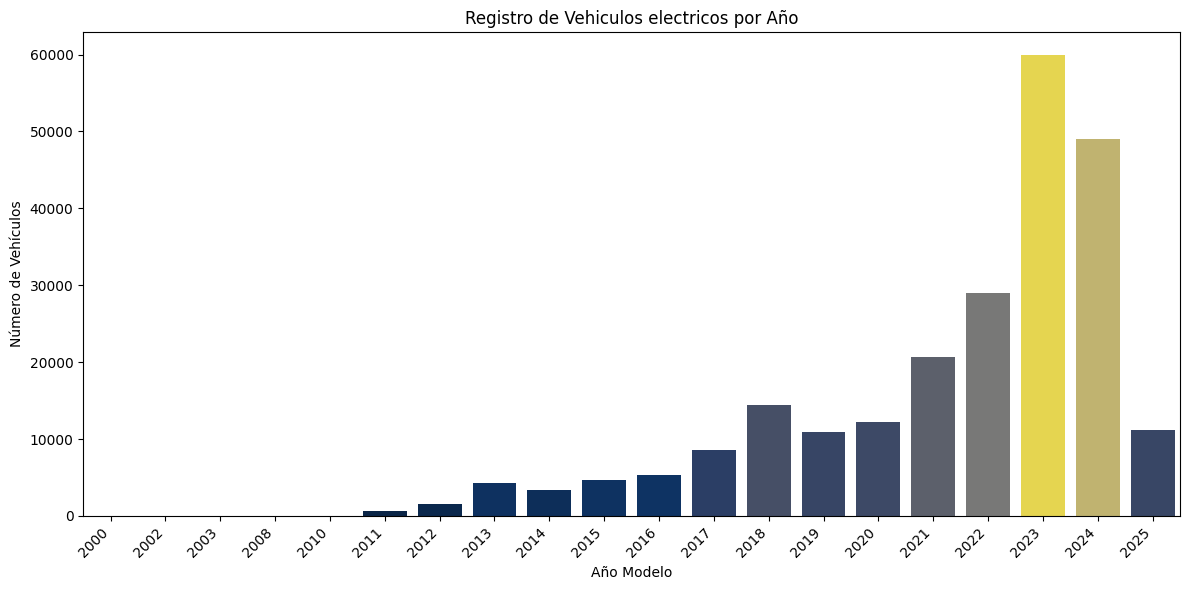

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Contar el número de vehículos por año modelo
conteo_por_año = vehiculos_electricos['Model Year'].value_counts().sort_index()
conteo_por_año_df = pd.DataFrame({'Año modelo': conteo_por_año.index, 'Vehiculos': conteo_por_año.values})

# Normalizacion de colores para el gráfico
norm = plt.Normalize(conteo_por_año_df['Vehiculos'].min(), conteo_por_año_df['Vehiculos'].max())
cmap = plt.cm.cividis 
colors = cmap(norm(conteo_por_año_df['Vehiculos']))

# Convertir el array de NumPy a una lista
color_list = colors.tolist()

# Crear el gráfico de barras con Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Año modelo', y='Vehiculos', data=conteo_por_año_df, palette=color_list)
plt.title('Registro de Vehiculos electricos por Año')
plt.xlabel('Año Modelo')
plt.ylabel('Número de Vehículos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Registro de vehiculos electricos por fabricante

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3876\3367998810.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vehiculos', y='Fabricante', data=conteo_por_fabricante_df, palette=color_list) # Intercambiamos x e y


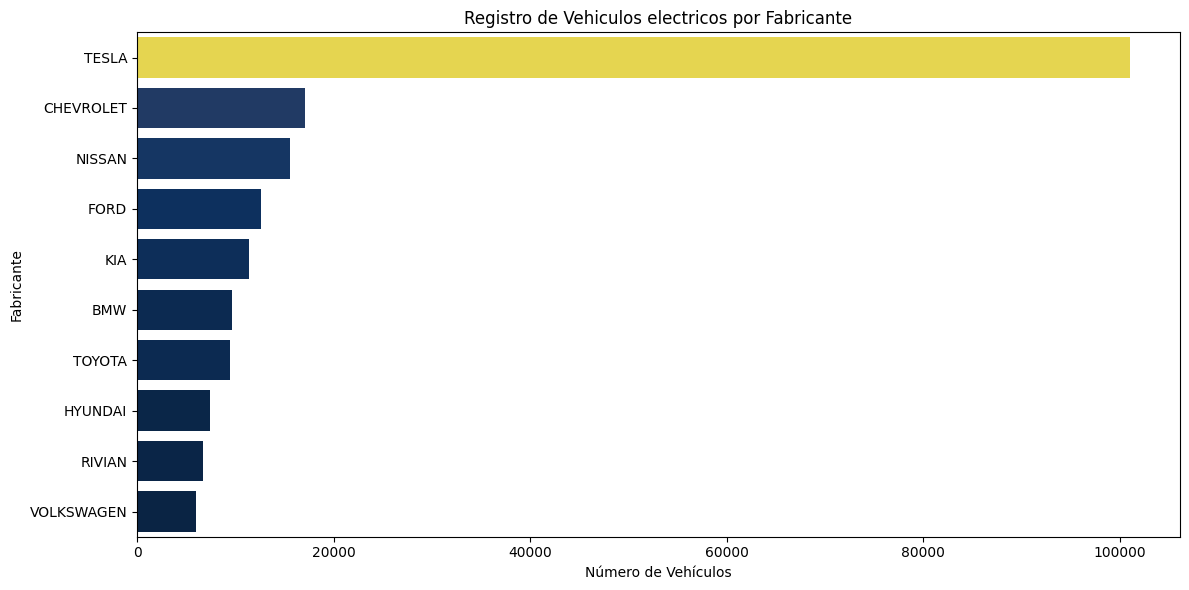

In [22]:
# Conteo de mayores fabricantes
conteo_por_fabricante = vehiculos_electricos['Make'].value_counts().head(10)
conteo_por_fabricante_df = pd.DataFrame({'Fabricante': conteo_por_fabricante.index, 'Vehiculos': conteo_por_fabricante.values})

# Normalizacion de colores para el gráfico
norm = plt.Normalize(conteo_por_fabricante_df['Vehiculos'].min(), conteo_por_fabricante_df['Vehiculos'].max())
cmap = plt.cm.cividis
colors = cmap(norm(conteo_por_fabricante_df['Vehiculos']))

# Convertir el array de NumPy a una lista
color_list = colors.tolist()

# Crear el gráfico de barras horizontal con Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Vehiculos', y='Fabricante', data=conteo_por_fabricante_df, palette=color_list) # Intercambiamos x e y
plt.title('Registro de Vehiculos electricos por Fabricante')
plt.xlabel('Número de Vehículos')
plt.ylabel('Fabricante')
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

### Distribucion por tipo de vehiculo electrico

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3876\2810499639.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cantidad', y='Tipo de Vehículo Eléctrico', data=type_counts_df, palette=sns.color_palette('cividis', n_colors=len(type_counts)))


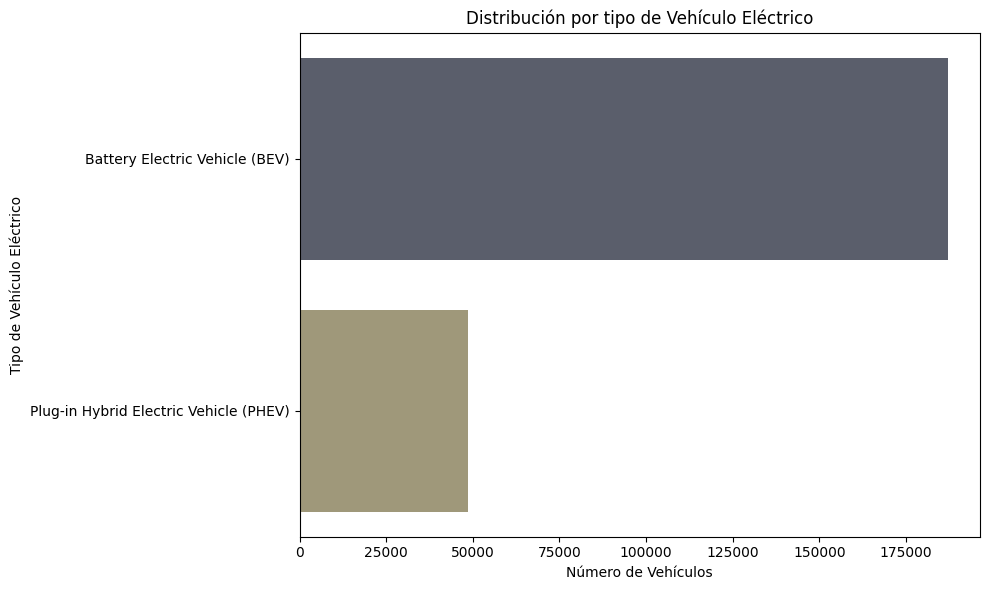

In [23]:
# Contar la frecuencia de cada tipo de vehículo eléctrico
type_counts = vehiculos_electricos['Electric Vehicle Type'].value_counts()
type_counts_df = pd.DataFrame({'Tipo de Vehículo Eléctrico': type_counts.index, 'Cantidad': type_counts.values})

# Crear el gráfico de barras con Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Cantidad', y='Tipo de Vehículo Eléctrico', data=type_counts_df, palette=sns.color_palette('cividis', n_colors=len(type_counts)))
plt.title("Distribución por tipo de Vehículo Eléctrico")
plt.xlabel("Número de Vehículos")
plt.ylabel("Tipo de Vehículo Eléctrico")
plt.tight_layout()
plt.show()

### Distribucion de autonomia electrica

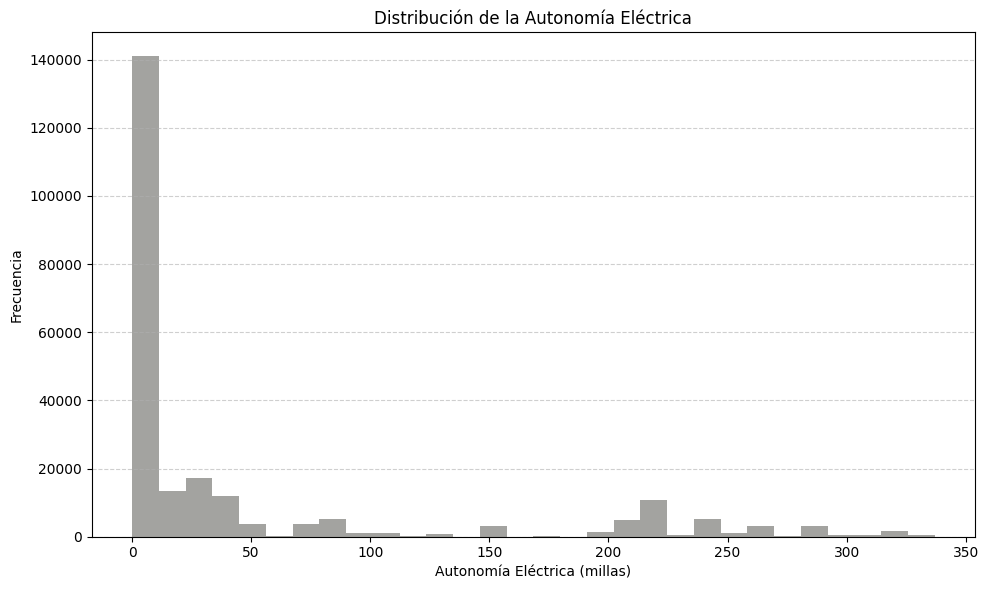

In [24]:
# Histograma de distribución de la autonomía eléctrica
plt.figure(figsize=(10, 6))
plt.hist(vehiculos_electricos['Electric Range'].dropna(), bins=30, color=sns.color_palette('cividis', 1)[0], alpha=0.7)
plt.title('Distribución de la Autonomía Eléctrica')
plt.xlabel('Autonomía Eléctrica (millas)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Elegibilidad como Vehiculo de combustible alternativo limpio (CAFV)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3876\3838788968.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vehiculos', y='CAFV', data=conteo_cafv_df, palette='cividis') # Intercambiamos x e y


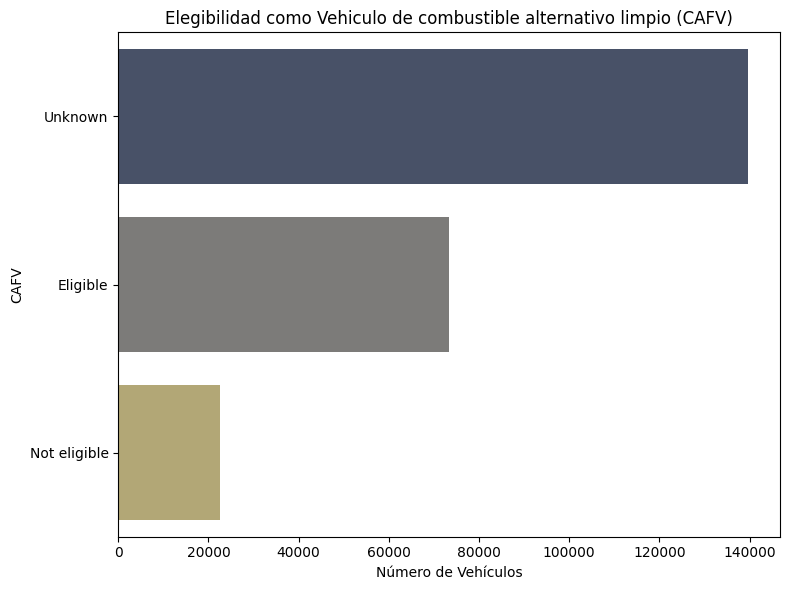

In [25]:
# Conteo de frecuencia de CAFV
conteo_cafv = vehiculos_electricos['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()
conteo_cafv_df = pd.DataFrame({'CAFV': conteo_cafv.index, 'Vehiculos': conteo_cafv.values})

# Resumiendo los datos
resumido = {
    'Eligibility unknown as battery range has not been researched': 'Unknown',
    'Clean Alternative Fuel Vehicle Eligible': 'Eligible',
    'Not eligible due to low battery range': 'Not eligible'
}
conteo_cafv_df['CAFV'] = conteo_cafv_df['CAFV'].map(resumido)

# Crear el gráfico de barras horizontal con Seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x='Vehiculos', y='CAFV', data=conteo_cafv_df, palette='cividis') # Intercambiamos x e y
plt.title('Elegibilidad como Vehiculo de combustible alternativo limpio (CAFV)')
plt.xlabel('Número de Vehículos') # Invertimos las etiquetas de los ejes también
plt.ylabel('CAFV')
plt.yticks(rotation=0) # Ajustamos la rotación de las etiquetas del eje y
plt.tight_layout()
plt.show()

## Modelo de clasificacion

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Definir la variable objetivo y las características
target_column = 'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
X = vehiculos_electricos.drop(columns=[target_column])
y = vehiculos_electricos[target_column]

# Identificar tipos de columnas
categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Crear preprocesadores
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Crear el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Resultados de los modelos:

Modelo: Logistic Regression
Accuracy: 0.9999
Classification Report:
                                                               precision    recall  f1-score   support

                     Clean Alternative Fuel Vehicle Eligible       1.00      1.00      1.00     14664
Eligibility unknown as battery range has not been researched       1.00      1.00      1.00     27952
                       Not eligible due to low battery range       1.00      1.00      1.00      4523

                                                    accuracy                           1.00     47139
                                                   macro avg       1.00      1.00      1.00     47139
                                                weighted avg       1.00      1.00      1.00     47139

Confusion Matrix:
 [[14659     0     5]
 [    0 27952     0]
 [    0     1  4522]]


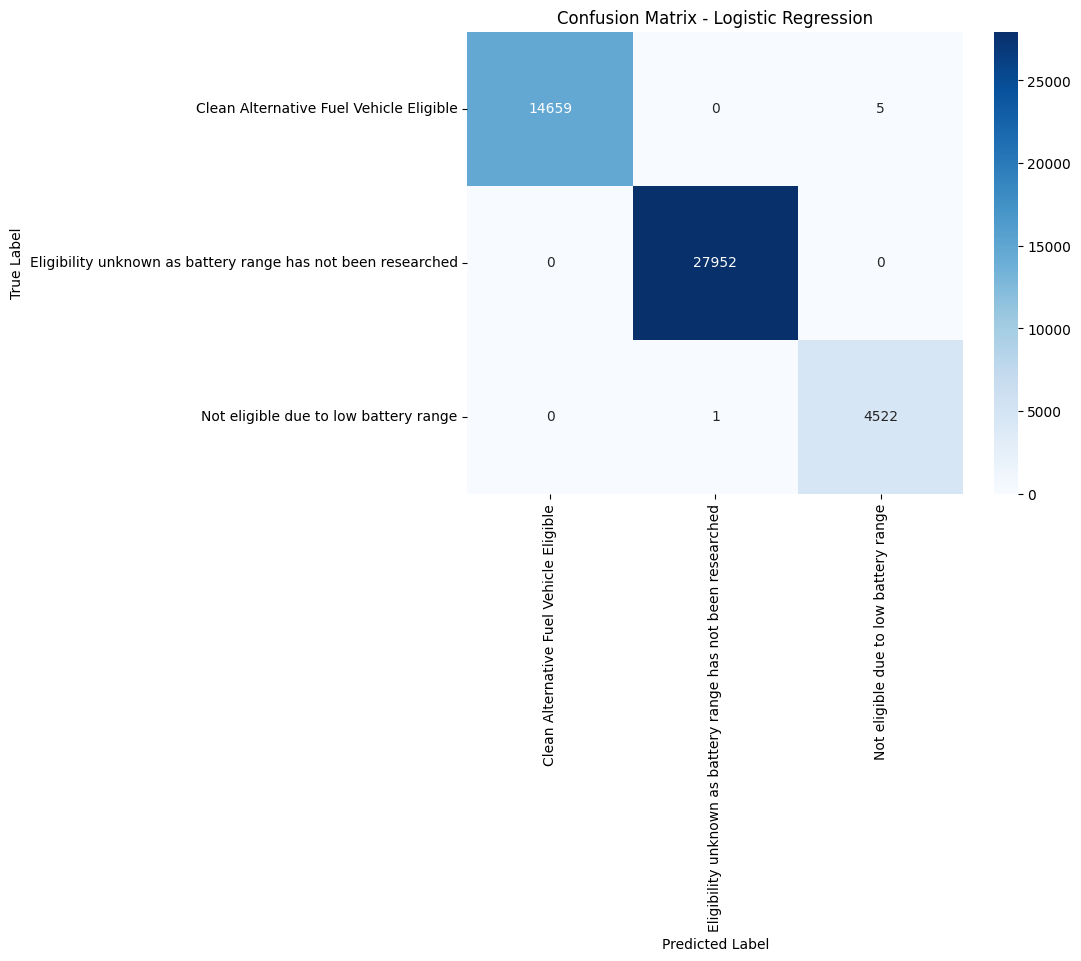


Modelo: Decision Tree
Accuracy: 1.0000
Classification Report:
                                                               precision    recall  f1-score   support

                     Clean Alternative Fuel Vehicle Eligible       1.00      1.00      1.00     14664
Eligibility unknown as battery range has not been researched       1.00      1.00      1.00     27952
                       Not eligible due to low battery range       1.00      1.00      1.00      4523

                                                    accuracy                           1.00     47139
                                                   macro avg       1.00      1.00      1.00     47139
                                                weighted avg       1.00      1.00      1.00     47139

Confusion Matrix:
 [[14664     0     0]
 [    0 27952     0]
 [    0     0  4523]]


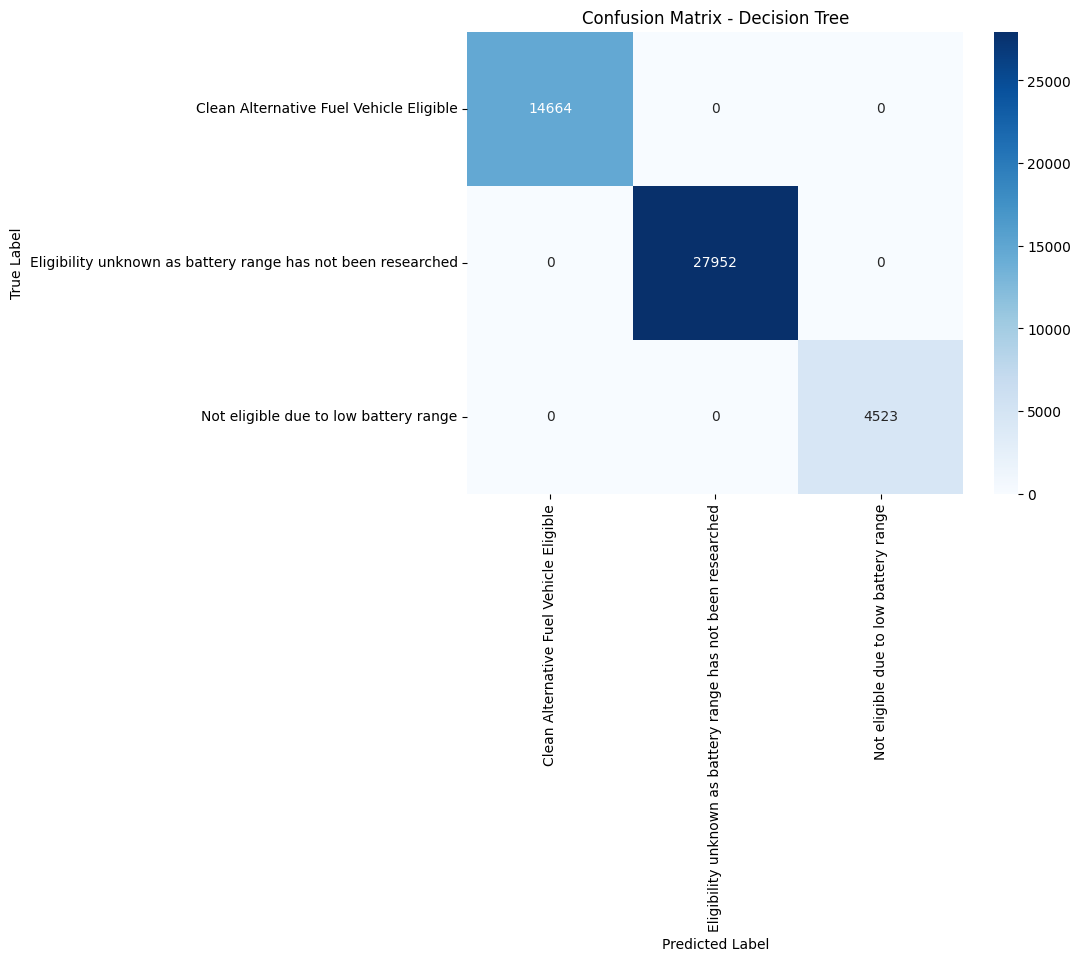


Modelo: K-Nearest Neighbors
Accuracy: 0.9914
Classification Report:
                                                               precision    recall  f1-score   support

                     Clean Alternative Fuel Vehicle Eligible       0.98      0.99      0.99     14664
Eligibility unknown as battery range has not been researched       1.00      1.00      1.00     27952
                       Not eligible due to low battery range       0.98      0.93      0.96      4523

                                                    accuracy                           0.99     47139
                                                   macro avg       0.99      0.98      0.98     47139
                                                weighted avg       0.99      0.99      0.99     47139

Confusion Matrix:
 [[14561    18    85]
 [    2 27948     2]
 [  293     7  4223]]


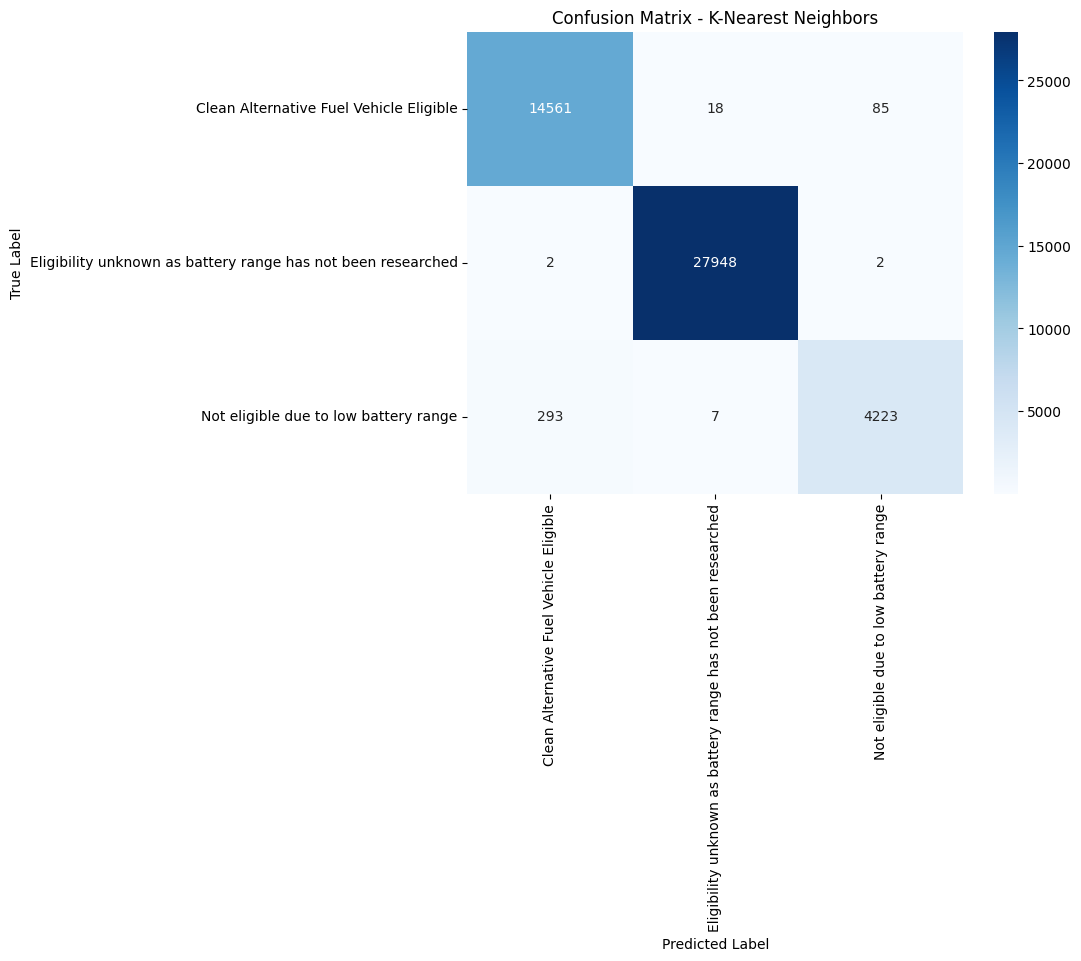

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Definir y entrenar los modelos
models = {
    'Logistic Regression': Pipeline(steps=[('preprocessor', preprocessor),
                                           ('classifier', LogisticRegression(solver='liblinear', random_state=42, multi_class='auto'))]),
    'Decision Tree': Pipeline(steps=[('preprocessor', preprocessor),
                                      ('classifier', DecisionTreeClassifier(random_state=42))]),
    'K-Nearest Neighbors': Pipeline(steps=[('preprocessor', preprocessor),
                                          ('classifier', KNeighborsClassifier(n_neighbors=5))])
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    results[name] = {'accuracy': accuracy, 'classification_report': report, 'confusion_matrix': cm}

# Comparar los resultados
print("Resultados de los modelos:")
for name, result in results.items():
    print(f"\nModelo: {name}")
    print(f"Accuracy: {result['accuracy']:.4f}")
    print("Classification Report:\n", result['classification_report'])
    print("Confusion Matrix:\n", result['confusion_matrix'])

    # Visualizar la matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=y.unique(), yticklabels=y.unique())
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()